Use this as a starter code when creating the results of your model. For the most part, this code is similar to the "main.ipynb", but there are a small number of IMPORTANT changes:

1- In order to ensure fairness when comparing the different models, we need to make sure they are being trained/tested on the same amount of data and the exact same data points. Here we are using the first 800_000 rows of data, spliting it into one 700k chunck for training and 100k samples for testing (technecally this is the validation set, but you get my point). The reason the amount of data is set to 800_000 and not more is because the first ~800_000 rows belong to a single experiment_id and then after that, the data belongs to another experiment_id. In each experimient ID, the networking algoirthms used (congestion control, ABR, ...) are different and therefore, the data is also going to come from another distribution which makes it harder for the model to predict. So please stick to this 700k/100k split. However, if your model really does need more data, then we can think of something.

**2- In the previous code, it was using "df_model = df_model.sample(n=sample_size, random_state=42)" to create a subset of the large dataset for training, this is INCORRECT. Since our data is timeseries, randomly sampling from it ruins the temporal aspect of it. In this version, it uses "df_model = df_model.iloc[:sample_size]" which gets the first n samples, in order. If you also used the sample function to create your model, you will have to retrain it. **

3- As stated in the Team's message, we want to plot the models performance for each metric. For this, we will only plot the first 200 samples of the test set. This is to make sure our plots look the same

4- The main thing we want to add compared to the progress report, is quantile regression. There are a lot of material online about it so I wont go into detail, but for our results, we want to train models for 25-75 quantile coverage as well as 5-95 quantile coverage. So for rtt@1,2,3 and delivery_rate@1,2,3 steps into the future, for each case, you need to train for these two quantiles. For the quantile models, we care about two metrics: the coverage percent and the average interval width

In [1]:
!pip install numpy pandas matplotlib requests xgboost catboost

# Step 0: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Step 1: Load the dataset 
# Will check if the dataset is already downloaded, if not, download it.
# As we disscussed, the entire dataset is huge. For now, we will work the data of only one day. However, we can add more data later.
try:
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")
except FileNotFoundError:
    response = requests.get("https://storage.googleapis.com/puffer-data-release/2025-02-10T11_2025-02-11T11/video_sent_2025-02-10T11_2025-02-11T11.csv")
    with open("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv", 'wb') as f:
        f.write(response.content)
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")

# Step 2: Remove unnecessary columns & rename columns
#df = df.drop(columns=['session_id', 'channel', 'format'])
df = df.rename(columns={'time (ns GMT)': 'time'})
# make time relative to start of session and convert to seconds
df['time'] = (df['time'] - df['time'].min()) / 1e9

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


This is a nice compact function that handles the entire training pipeline

In [9]:
def train_catboost_time_series(df, target_metric='rtt', n_lags=1,
                               horizons=[1,2,4,8,16],
                               sample_size=800_000,
                               plot=True, plot_num=200,
                               save_models=True,
                               model_prefix="catboost_model_horizon_"):
    """
    Train CatBoost models for multiple specific horizons (e.g., 2,4,8,16) on time-series data,
    and automatically save each trained model to disk.

    Parameters
    ----------
    save_models : bool
        If True, saves each model as "<model_prefix><h>.cbm"
    model_prefix : str
        Prefix for saved filenames.

    Returns
    -------
    models : dict
        Dict: horizon → CatBoost model
    metrics : dict
        Dict: horizon → error metrics
    """

    print(f"\nPreparing dataset for target='{target_metric}', lags={n_lags}, horizons={horizons}")

    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']

    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]

    # Build lag and future targets
    dfs = []
    print("Adding lag & future target features per session...")
    for sid, group in tqdm(df_numeric.groupby('session_id', sort=False),
                           total=df_numeric['session_id'].nunique()):
        g = group.sort_values('time').copy()

        for lag in range(1, n_lags + 1):
            for col in feature_cols:
                g[f"{col}_lag{lag}"] = g[col].shift(lag)

        for horizon in horizons:
            g[f"{target_metric}_next{horizon}"] = g[target_metric].shift(-horizon)

        dfs.append(g)

    df_model = pd.concat(dfs, axis=0).dropna(
        subset=[f"{target_metric}_next{h}" for h in horizons]
    ).reset_index(drop=True)

    if len(df_model) > sample_size:
        df_model = df_model.iloc[:sample_size].reset_index(drop=True)

    df_model = df_model.drop(columns=['session_id', 'time'], errors='ignore')

    feature_cols = [
        c for c in df_model.columns
        if (c.startswith(tuple(base_features)) or "_lag" in c)
        and not c.startswith(f"{target_metric}_next")
    ]

    X = df_model[feature_cols]

    train_size = int(len(df_model) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

    models = {}
    metrics = {}

    # Train each horizon
    for horizon in horizons:
        y = df_model[f"{target_metric}_next{horizon}"]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        cat_model = CatBoostRegressor(
            iterations=2000,
            learning_rate=0.05,
            depth=8,
            subsample=0.8,
            random_seed=42,
            loss_function="MAE",
            task_type="CPU",
            verbose=200
        )

        train_pool = Pool(X_train, y_train)
        test_pool = Pool(X_test, y_test)

        cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

        # Save model
        if save_models:
            filename = f"{model_prefix}{horizon}.cbm"
            print(f"Saving model: {filename}")
            cat_model.save_model(filename)

        y_pred_train = cat_model.predict(X_train)
        y_pred_test = cat_model.predict(X_test)

        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)

        print(f"\nHorizon {horizon}-step:")
        print(f"  Train MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
        print(f"  Test  MAE: {mae_test:.4f}, R²: {r2_test:.4f}")

        models[horizon] = cat_model
        metrics[horizon] = {
            "train_MAE": mae_train,
            "train_R2": r2_train,
            "test_MAE": mae_test,
            "test_R2": r2_test
        }

        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(y_test.values[:plot_num], label="Actual", linewidth=2)
            plt.plot(y_pred_test[:plot_num], label="Predicted", linestyle="--")
            plt.title(f"{target_metric} Prediction ({horizon}-Step Horizon)")
            plt.xlabel("Time Steps")
            plt.ylabel(target_metric)
            plt.legend()
            plt.tight_layout()
            plt.show()

            # Feature importance
            importances = cat_model.get_feature_importance()
            indices = np.argsort(importances)[::-1]

            plt.figure(figsize=(6, 4))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(range(len(importances)), np.array(X.columns)[indices], rotation=30)
            plt.title(f"Feature Importance (Horizon={horizon})")
            plt.tight_layout()
            plt.show()

    return models, metrics



Preparing dataset for target='rtt', lags=10, horizons=[1, 2, 4, 8, 16]
Adding lag & future target features per session...


100%|██████████| 3595/3595 [01:10<00:00, 51.17it/s]


Training size: 640000, Test size: 160000
0:	learn: 61179.2266178	test: 35177.1215598	best: 35177.1215598 (0)	total: 178ms	remaining: 5m 55s
200:	learn: 13391.8681081	test: 13529.6118654	best: 13529.6118654 (200)	total: 25.5s	remaining: 3m 47s
400:	learn: 13102.4864480	test: 13392.0483334	best: 13392.0483334 (400)	total: 47.9s	remaining: 3m 11s
600:	learn: 12956.0084334	test: 13322.4425434	best: 13322.4425434 (600)	total: 1m 14s	remaining: 2m 52s
800:	learn: 12840.3020719	test: 13276.2848024	best: 13275.7810182 (796)	total: 1m 42s	remaining: 2m 33s
1000:	learn: 12735.7289596	test: 13249.7182667	best: 13249.2972165 (999)	total: 2m 5s	remaining: 2m 5s
1200:	learn: 12649.3418974	test: 13230.7788414	best: 13230.1293606 (1174)	total: 2m 28s	remaining: 1m 39s
1400:	learn: 12575.0590524	test: 13219.9998510	best: 13219.9670102 (1398)	total: 2m 54s	remaining: 1m 14s
1600:	learn: 12500.6705312	test: 13217.7540097	best: 13215.4031937 (1520)	total: 3m 17s	remaining: 49.2s
1800:	learn: 12439.3620975

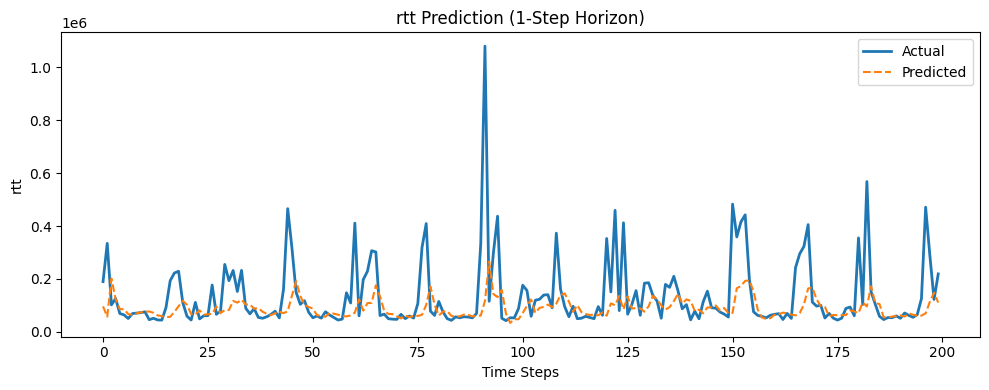

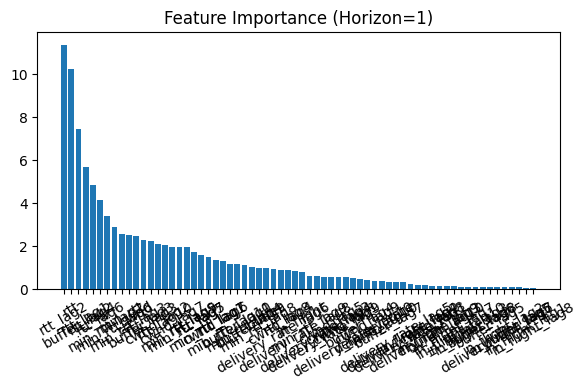

0:	learn: 61189.7448350	test: 35212.0266938	best: 35212.0266938 (0)	total: 171ms	remaining: 5m 40s
200:	learn: 13505.6332534	test: 13836.3300352	best: 13836.3300352 (200)	total: 23.6s	remaining: 3m 31s
400:	learn: 13238.5921819	test: 13737.8442093	best: 13737.8442093 (400)	total: 46.8s	remaining: 3m 6s
600:	learn: 13108.9387564	test: 13685.2721363	best: 13685.2721363 (600)	total: 1m 10s	remaining: 2m 44s
800:	learn: 12999.7173020	test: 13651.0536990	best: 13651.0536990 (800)	total: 1m 34s	remaining: 2m 21s
1000:	learn: 12900.5093696	test: 13634.8092024	best: 13634.8086315 (999)	total: 1m 57s	remaining: 1m 57s
1200:	learn: 12824.5552932	test: 13617.0213671	best: 13617.0190254 (1199)	total: 2m 20s	remaining: 1m 33s
1400:	learn: 12756.7852620	test: 13607.6970061	best: 13607.4801453 (1388)	total: 2m 45s	remaining: 1m 10s
1600:	learn: 12681.5219721	test: 13602.5387355	best: 13602.3144008 (1598)	total: 3m 13s	remaining: 48.1s
1800:	learn: 12614.5303104	test: 13599.2073446	best: 13598.4428398

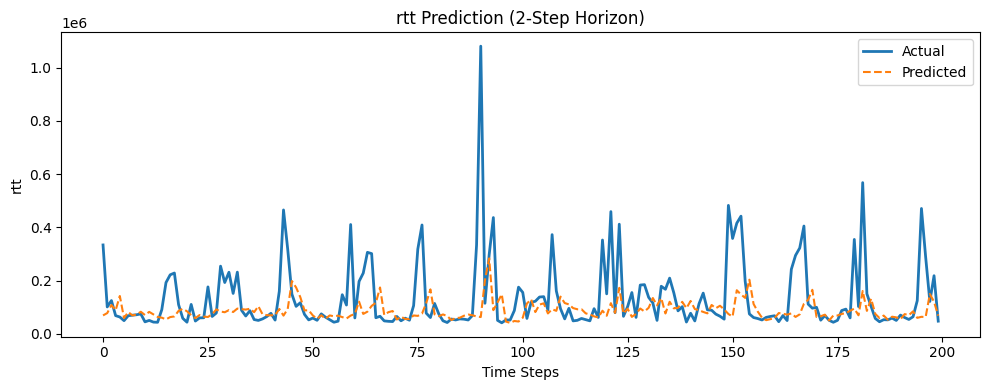

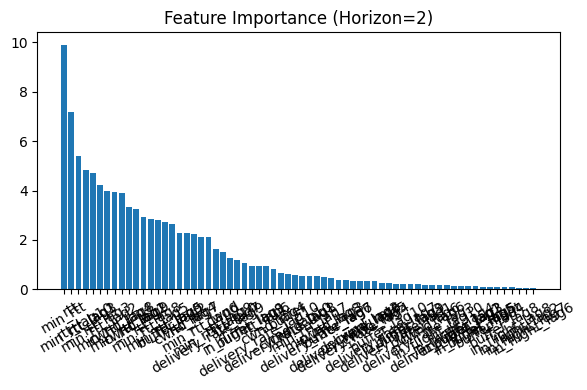

0:	learn: 61179.7846480	test: 35389.6797854	best: 35389.6797854 (0)	total: 175ms	remaining: 5m 50s
200:	learn: 13677.3027938	test: 14166.0190578	best: 14166.0190578 (200)	total: 28.1s	remaining: 4m 11s
400:	learn: 13409.4641542	test: 14092.0435826	best: 14091.7965032 (398)	total: 54.9s	remaining: 3m 38s
600:	learn: 13272.0514691	test: 14048.2402883	best: 14048.0802694 (598)	total: 1m 19s	remaining: 3m 4s
800:	learn: 13167.3132903	test: 14023.9594281	best: 14023.6149752 (794)	total: 1m 44s	remaining: 2m 36s
1000:	learn: 13081.4121552	test: 14006.5899856	best: 14006.2110177 (995)	total: 2m 7s	remaining: 2m 7s
1200:	learn: 13006.8226722	test: 13994.0940635	best: 13994.0940635 (1200)	total: 2m 30s	remaining: 1m 40s
1400:	learn: 12932.4527230	test: 13984.5481602	best: 13984.4357627 (1393)	total: 2m 53s	remaining: 1m 14s
1600:	learn: 12870.8546364	test: 13977.8486618	best: 13977.7135570 (1590)	total: 3m 18s	remaining: 49.4s
1800:	learn: 12808.4630210	test: 13974.4084217	best: 13974.3450216 (

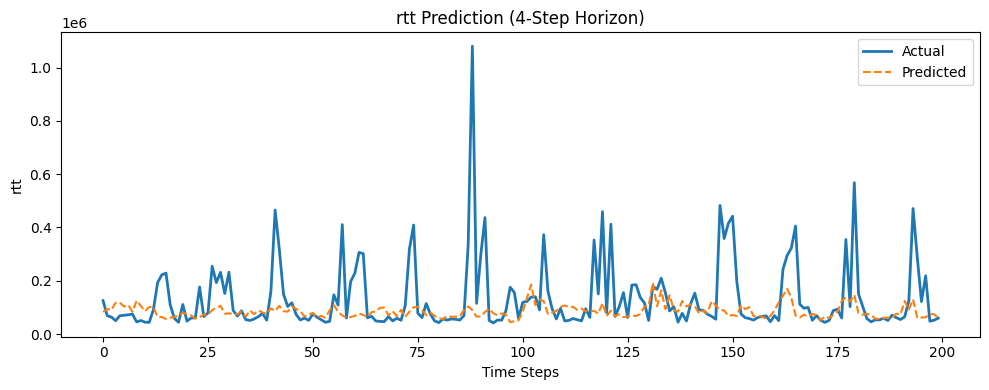

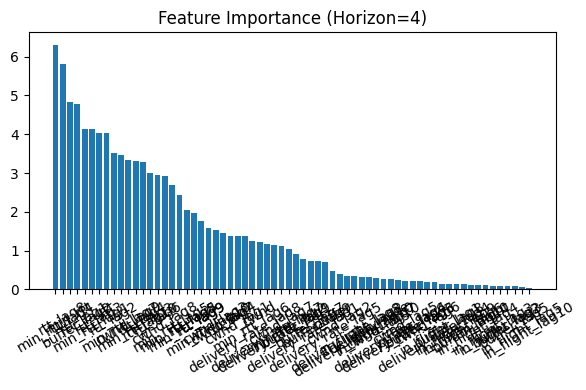

0:	learn: 61163.3644682	test: 35378.4175667	best: 35378.4175667 (0)	total: 151ms	remaining: 5m 2s
200:	learn: 13840.5197656	test: 14428.3291862	best: 14428.3291862 (200)	total: 24.3s	remaining: 3m 37s
400:	learn: 13567.6850331	test: 14342.1206087	best: 14342.1206087 (400)	total: 47.5s	remaining: 3m 9s
600:	learn: 13430.4076909	test: 14287.8870880	best: 14287.8870880 (600)	total: 1m 12s	remaining: 2m 48s
800:	learn: 13322.3560872	test: 14254.9462079	best: 14254.6699312 (795)	total: 1m 36s	remaining: 2m 24s
1000:	learn: 13239.5483640	test: 14238.6214905	best: 14238.5790567 (998)	total: 2m	remaining: 2m
1200:	learn: 13158.6750016	test: 14220.6439170	best: 14220.4390306 (1198)	total: 2m 26s	remaining: 1m 37s
1400:	learn: 13085.4740105	test: 14209.6479177	best: 14209.6479177 (1400)	total: 2m 54s	remaining: 1m 14s
1600:	learn: 13027.8687316	test: 14206.0844917	best: 14204.7041051 (1570)	total: 3m 17s	remaining: 49.2s
1800:	learn: 12971.2986544	test: 14200.0044774	best: 14199.9347959 (1799)	t

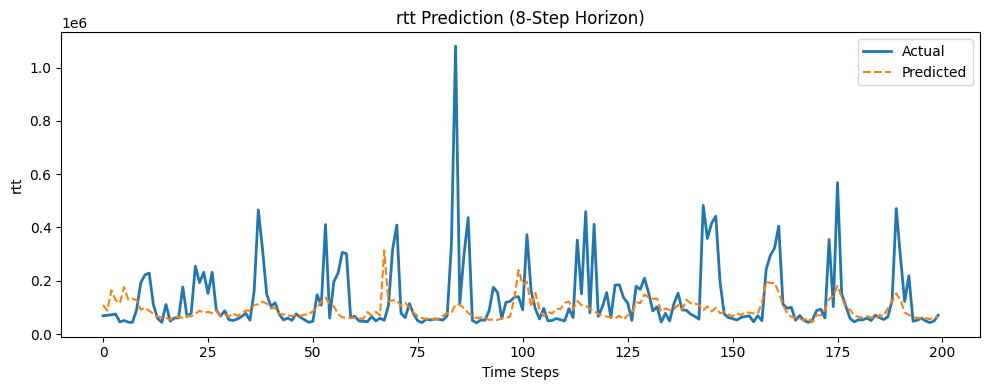

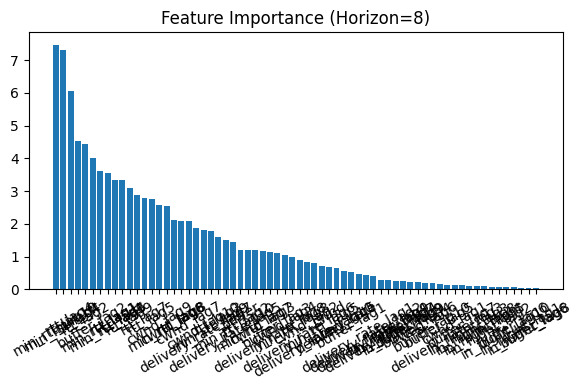

0:	learn: 61188.6228775	test: 35250.0728691	best: 35250.0728691 (0)	total: 169ms	remaining: 5m 38s
200:	learn: 13919.8140423	test: 14557.6682961	best: 14557.5940363 (198)	total: 28s	remaining: 4m 11s
400:	learn: 13693.6394309	test: 14477.6313801	best: 14477.6313801 (400)	total: 51.9s	remaining: 3m 26s
600:	learn: 13563.0252320	test: 14426.4583776	best: 14426.4583776 (600)	total: 1m 16s	remaining: 2m 59s
800:	learn: 13476.0625696	test: 14404.7521427	best: 14404.1432776 (796)	total: 1m 42s	remaining: 2m 34s
1000:	learn: 13393.2236357	test: 14387.9905777	best: 14387.9905777 (1000)	total: 2m 5s	remaining: 2m 5s
1200:	learn: 13323.4500381	test: 14372.7419935	best: 14372.7354430 (1199)	total: 2m 31s	remaining: 1m 40s
1400:	learn: 13258.3925264	test: 14360.5524417	best: 14360.5524417 (1400)	total: 2m 53s	remaining: 1m 14s
1600:	learn: 13194.7538471	test: 14348.7995048	best: 14348.5679646 (1598)	total: 3m 17s	remaining: 49.2s
1800:	learn: 13139.5210861	test: 14344.3593949	best: 14344.2696438 (

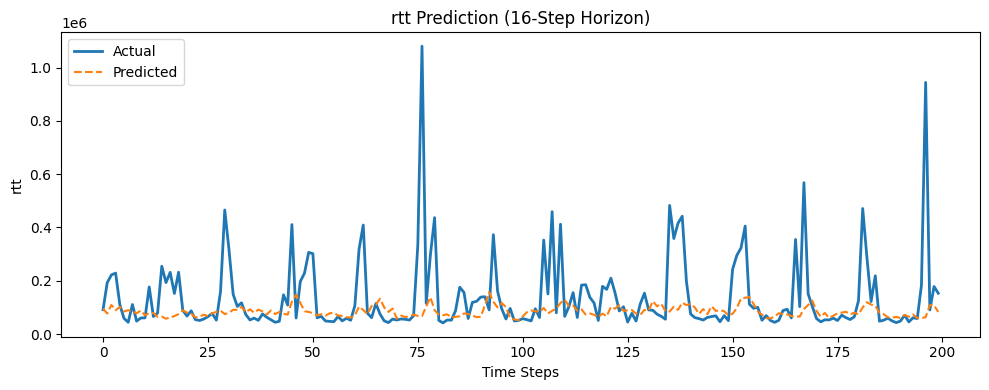

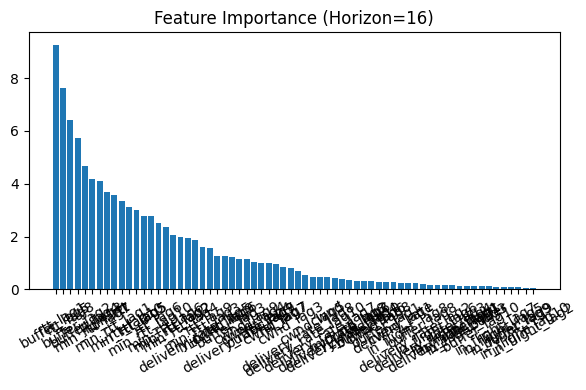

In [10]:
model, metrics = train_catboost_time_series(df, target_metric='rtt', n_lags=10, plot_num=200)


Preparing dataset for target='delivery_rate', lags=10, horizons=[1, 2, 4, 8, 16]
Adding lag & future target features per session...


100%|██████████| 3595/3595 [00:52<00:00, 68.12it/s]


Training size: 640000, Test size: 160000
0:	learn: 6835791.7530819	test: 4638137.5371368	best: 4638137.5371368 (0)	total: 175ms	remaining: 5m 49s
200:	learn: 2641046.3000672	test: 1969815.1734770	best: 1969815.1734770 (200)	total: 24.8s	remaining: 3m 41s
400:	learn: 2489026.8672164	test: 1908775.3348801	best: 1908775.3348801 (400)	total: 49.2s	remaining: 3m 16s
600:	learn: 2423683.7379337	test: 1886035.5778902	best: 1886035.5778902 (600)	total: 1m 16s	remaining: 2m 58s
800:	learn: 2383147.1782069	test: 1873786.5841558	best: 1873765.7271540 (799)	total: 1m 41s	remaining: 2m 31s
1000:	learn: 2357696.6247421	test: 1867977.3443949	best: 1867977.3443949 (1000)	total: 2m 6s	remaining: 2m 6s
1200:	learn: 2335238.6533971	test: 1862212.9380196	best: 1862206.3471033 (1197)	total: 2m 31s	remaining: 1m 40s
1400:	learn: 2318744.7652714	test: 1858437.1411471	best: 1858437.1411471 (1400)	total: 2m 56s	remaining: 1m 15s
1600:	learn: 2303504.1400299	test: 1855739.7186676	best: 1855738.2105404 (1599)	to

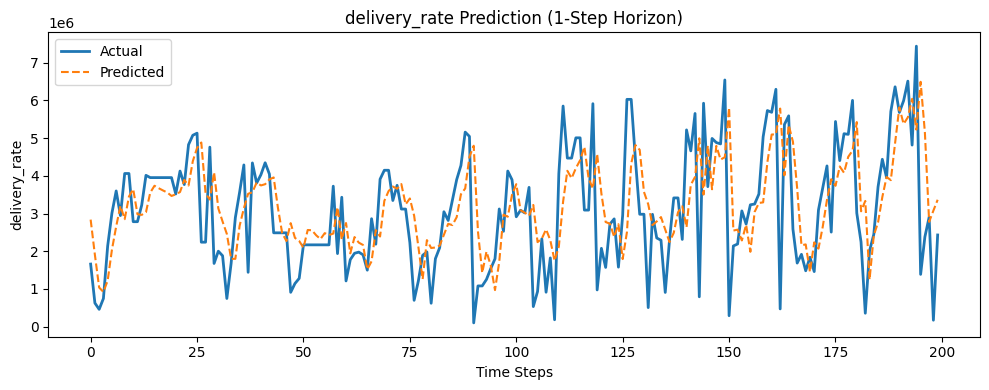

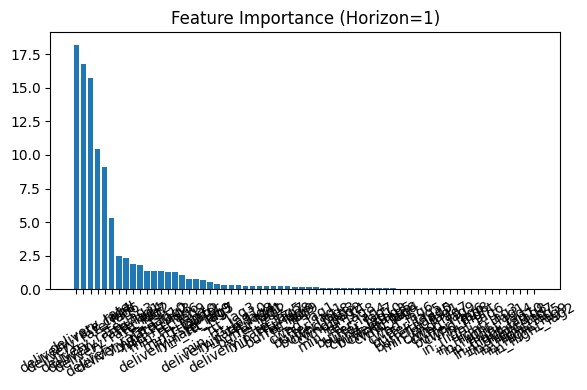

0:	learn: 6874835.2072141	test: 4631633.3692249	best: 4631633.3692249 (0)	total: 199ms	remaining: 6m 38s
200:	learn: 2526879.7932145	test: 1976062.3666006	best: 1976062.3666006 (200)	total: 28.1s	remaining: 4m 11s
400:	learn: 2402652.5025364	test: 1924993.6115072	best: 1924993.6115072 (400)	total: 53.8s	remaining: 3m 34s
600:	learn: 2353347.2405848	test: 1904827.2115573	best: 1904827.2115573 (600)	total: 1m 20s	remaining: 3m 7s
800:	learn: 2319817.9602397	test: 1893564.2350251	best: 1893564.2350251 (800)	total: 1m 47s	remaining: 2m 41s
1000:	learn: 2295668.4735662	test: 1886792.9065945	best: 1886792.9065945 (1000)	total: 2m 13s	remaining: 2m 13s
1200:	learn: 2274734.3330741	test: 1882306.7115987	best: 1882306.7115987 (1200)	total: 2m 38s	remaining: 1m 45s
1400:	learn: 2259308.7954974	test: 1878640.6731879	best: 1878640.6731879 (1400)	total: 3m 4s	remaining: 1m 18s
1600:	learn: 2243947.1936162	test: 1876160.0235391	best: 1876160.0235391 (1600)	total: 3m 27s	remaining: 51.8s
1800:	learn:

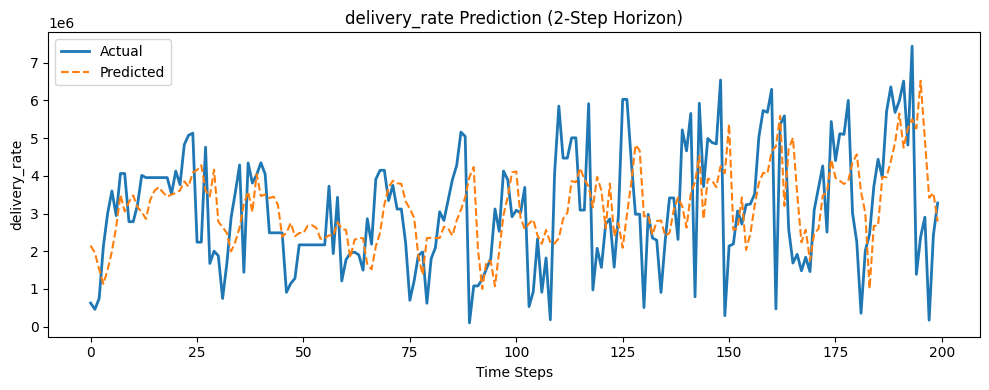

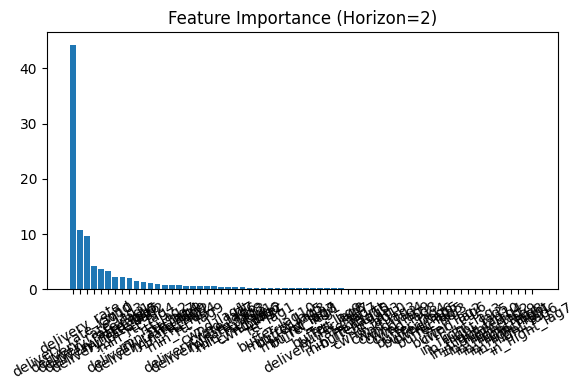

0:	learn: 6841056.6961918	test: 4638364.9989789	best: 4638364.9989789 (0)	total: 179ms	remaining: 5m 57s
200:	learn: 2700399.5563131	test: 2107827.3036832	best: 2107827.3036832 (200)	total: 24.4s	remaining: 3m 38s
400:	learn: 2597400.7335429	test: 2062871.6534902	best: 2062871.6534902 (400)	total: 49.2s	remaining: 3m 16s
600:	learn: 2544538.5820818	test: 2042872.8845713	best: 2042872.8845713 (600)	total: 1m 14s	remaining: 2m 53s
800:	learn: 2516361.4831028	test: 2033751.6134584	best: 2033751.6134584 (800)	total: 1m 37s	remaining: 2m 25s
1000:	learn: 2488355.4635815	test: 2027255.0520836	best: 2027255.0520836 (1000)	total: 1m 58s	remaining: 1m 58s
1200:	learn: 2468534.5432837	test: 2022548.9574291	best: 2022548.9574291 (1200)	total: 2m 21s	remaining: 1m 34s
1400:	learn: 2448715.3211241	test: 2019105.8800493	best: 2019105.8800493 (1400)	total: 2m 44s	remaining: 1m 10s
1600:	learn: 2432707.6886225	test: 2017203.2780527	best: 2017186.4398178 (1594)	total: 3m 6s	remaining: 46.5s
1800:	learn

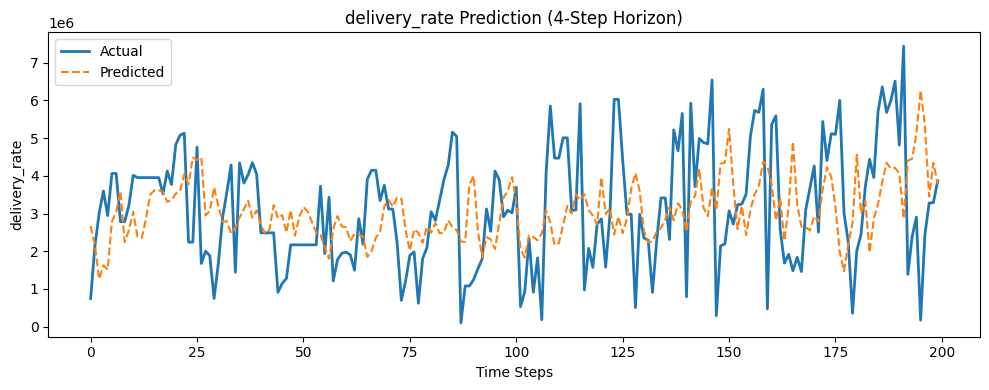

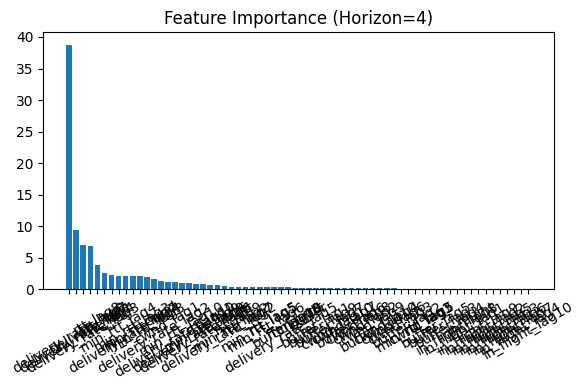

0:	learn: 6897634.0149644	test: 4644689.7297724	best: 4644689.7297724 (0)	total: 174ms	remaining: 5m 47s
200:	learn: 2944734.1609480	test: 2308005.1716917	best: 2308005.1716917 (200)	total: 23.7s	remaining: 3m 32s
400:	learn: 2849143.4680352	test: 2247298.9089868	best: 2247298.9089868 (400)	total: 46s	remaining: 3m 3s
600:	learn: 2787980.6942010	test: 2229877.4012409	best: 2229872.4431557 (593)	total: 1m 8s	remaining: 2m 38s
800:	learn: 2754145.0278582	test: 2223758.3725309	best: 2223697.4425903 (794)	total: 1m 31s	remaining: 2m 16s
1000:	learn: 2732610.9582858	test: 2220803.2997659	best: 2220803.2997659 (1000)	total: 1m 53s	remaining: 1m 53s
1200:	learn: 2710437.3391843	test: 2217347.7978954	best: 2217343.8452124 (1199)	total: 2m 17s	remaining: 1m 31s
1400:	learn: 2690200.3529394	test: 2215538.4672881	best: 2215514.6786921 (1396)	total: 2m 42s	remaining: 1m 9s
1600:	learn: 2675772.0184678	test: 2214387.8897002	best: 2214207.4535065 (1596)	total: 3m 8s	remaining: 47s
1800:	learn: 26620

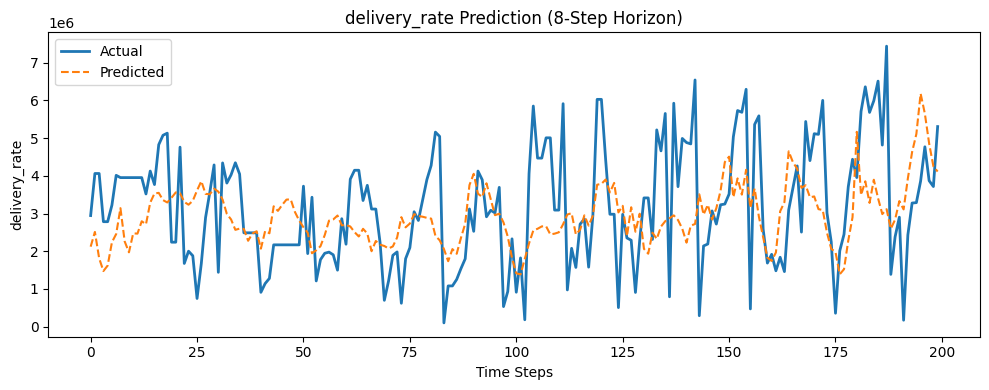

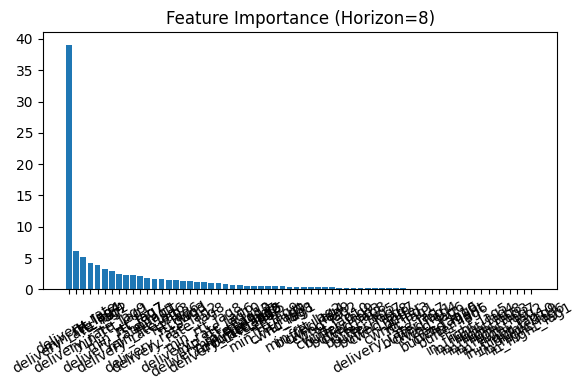

0:	learn: 6853148.7139092	test: 4600007.0400188	best: 4600007.0400188 (0)	total: 159ms	remaining: 5m 17s
200:	learn: 3182907.5797060	test: 2497809.1724576	best: 2497742.9574737 (198)	total: 22.5s	remaining: 3m 21s
400:	learn: 3074976.7594478	test: 2456361.6131553	best: 2456359.6352155 (399)	total: 45.4s	remaining: 3m
600:	learn: 3013402.0747061	test: 2449811.2807252	best: 2449811.2807252 (600)	total: 1m 8s	remaining: 2m 39s
800:	learn: 2973397.5926873	test: 2450475.9474237	best: 2448415.6426995 (640)	total: 1m 32s	remaining: 2m 18s
1000:	learn: 2946844.5909290	test: 2456905.3518079	best: 2448415.6426995 (640)	total: 1m 56s	remaining: 1m 56s
1200:	learn: 2923054.6649938	test: 2460140.5549050	best: 2448415.6426995 (640)	total: 2m 19s	remaining: 1m 33s
1400:	learn: 2904341.9609888	test: 2464939.2297296	best: 2448415.6426995 (640)	total: 2m 44s	remaining: 1m 10s
1600:	learn: 2886329.3910942	test: 2465262.5638034	best: 2448415.6426995 (640)	total: 3m 7s	remaining: 46.8s
1800:	learn: 2872152

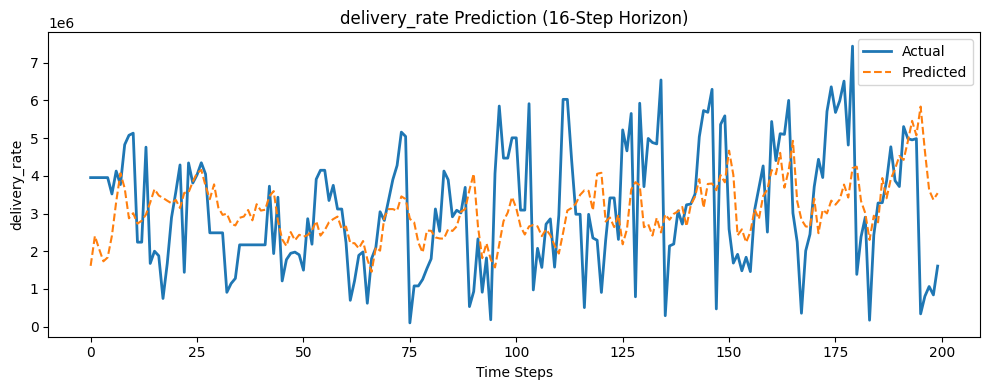

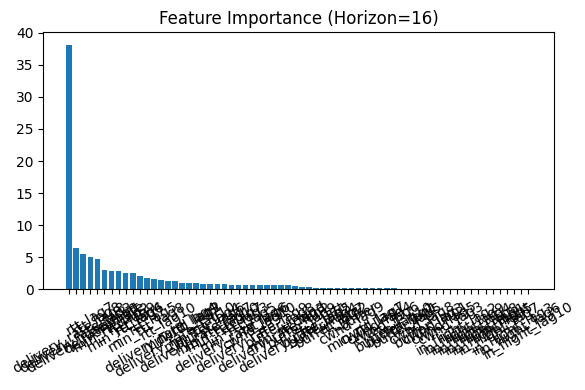

In [11]:
model, metrics = train_catboost_time_series(df, target_metric='delivery_rate', n_lags=10, plot_num=200)

In [12]:
def train_catboost_time_series_quantile(
    df,
    target_metric='rtt',
    n_lags=1,
    horizons=[2, 4, 8, 16],
    sample_size=800_000,
    quantiles=[0.25, 0.75],
    plot=True,
    plot_num=200
):
    """
    Train CatBoost quantile regression models for specified horizons on time-series data.
    Preprocessing matches the previous multi-horizon regression function exactly.

    Returns
    -------
    models : dict[horizon][quantile] -> CatBoostRegressor
    metrics : dict[horizon] -> coverage, interval width, and MAE per quantile
    """
    print(f"\nPreparing dataset for target='{target_metric}', lags={n_lags}, horizons={horizons}")

    # Numeric columns + identifiers
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']

    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]

    # ---- Session-wise lag & target creation ----
    dfs = []
    print("Adding lag & future target features per session...")
    for sid, group in tqdm(df_numeric.groupby('session_id', sort=False),
                           total=df_numeric['session_id'].nunique()):
        g = group.sort_values('time').copy()

        # Lag features
        for lag in range(1, n_lags + 1):
            for col in feature_cols:
                g[f"{col}_lag{lag}"] = g[col].shift(lag)

        # Future target for each horizon
        for horizon in horizons:
            g[f"{target_metric}_next{horizon}"] = g[target_metric].shift(-horizon)

        dfs.append(g)

    df_model = pd.concat(dfs, axis=0).dropna(
        subset=[f"{target_metric}_next{h}" for h in horizons]
    ).reset_index(drop=True)

    if len(df_model) > sample_size:
        df_model = df_model.iloc[:sample_size].reset_index(drop=True)

    # Drop non-feature columns
    df_model = df_model.drop(columns=['session_id', 'time'], errors='ignore')

    # Feature selection
    feature_cols = [
        c for c in df_model.columns
        if (c.startswith(tuple(base_features)) or "_lag" in c)
        and not c.startswith(f"{target_metric}_next")
    ]
    X = df_model[feature_cols]

    # Chronological split
    train_size = int(len(df_model) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

    models = {}
    metrics = {}

    # ---- Train quantile models per horizon ----
    for horizon in horizons:
        print(f"\n--- Horizon {horizon}-step ---")
        y = df_model[f"{target_metric}_next{horizon}"]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        models[horizon] = {}
        metrics[horizon] = {}
        preds = {}

        for q in quantiles:
            print(f"Training quantile={q}")
            cat_model = CatBoostRegressor(
                iterations=2000,
                learning_rate=0.05,
                depth=8,
                subsample=0.8,
                random_seed=42,
                loss_function=f'Quantile:alpha={q}',
                verbose=200
            )

            train_pool = Pool(X_train, y_train)
            test_pool = Pool(X_test, y_test)
            cat_model.fit(train_pool, eval_set=test_pool, use_best_model=False)

            y_pred = cat_model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)

            models[horizon][q] = cat_model
            metrics[horizon][q] = {'test_MAE': mae}
            preds[q] = y_pred

        # ---- Compute coverage and interval width ----
        if len(quantiles) >= 2:
            q_low, q_high = min(quantiles), max(quantiles)
            pred_low, pred_high = preds[q_low], preds[q_high]

            inside = (y_test.values >= pred_low) & (y_test.values <= pred_high)
            coverage = inside.mean() * 100.0
            avg_width = np.mean(pred_high - pred_low)

            metrics[horizon]['coverage'] = coverage
            metrics[horizon]['interval_width'] = avg_width

            print(f"Coverage: {coverage:.2f}% | Avg. interval width: {avg_width:.4f}")

        # ---- Plotting quantiles vs actual ----
        if plot and len(quantiles) >= 2:
            plt.figure(figsize=(10, 5))
            plt.plot(y_test.values[:plot_num], label='Actual', color='black', linewidth=2)

            q_low, q_high = min(quantiles), max(quantiles)
            plt.fill_between(
                np.arange(plot_num),
                preds[q_low][:plot_num],
                preds[q_high][:plot_num],
                color='skyblue',
                alpha=0.4,
                label=f'{int(q_low*100)}–{int(q_high*100)}% range'
            )

            plt.plot(preds[q_low][:plot_num], linestyle='--', color='blue', alpha=0.7, label=f'q={q_low}')
            plt.plot(preds[q_high][:plot_num], linestyle='--', color='blue', alpha=0.7, label=f'q={q_high}')

            plt.title(f'{target_metric} Quantile Predictions ({horizon}-Step Horizon)')
            plt.xlabel('Time Steps')
            plt.ylabel(target_metric)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return models, metrics


Preparing dataset for target='rtt', lags=10, horizons=[1, 4, 16]
Adding lag & future target features per session...


100%|██████████| 3595/3595 [00:49<00:00, 73.19it/s]



--- Horizon 1-step ---
Training quantile=0.25
0:	learn: 19518.6431083	test: 10882.0657409	best: 10882.0657409 (0)	total: 148ms	remaining: 4m 56s
200:	learn: 4223.3214920	test: 4408.6863573	best: 4408.6863573 (200)	total: 23.8s	remaining: 3m 33s
400:	learn: 4120.9023946	test: 4339.5872265	best: 4339.3193957 (393)	total: 49.9s	remaining: 3m 19s
600:	learn: 4071.8282695	test: 4296.0942491	best: 4296.0942491 (600)	total: 1m 14s	remaining: 2m 53s
800:	learn: 4035.7942519	test: 4269.7565840	best: 4269.7565840 (800)	total: 1m 41s	remaining: 2m 31s
1000:	learn: 4007.9257507	test: 4255.4735253	best: 4255.4735253 (1000)	total: 2m 5s	remaining: 2m 5s
1200:	learn: 3983.0956094	test: 4242.3884845	best: 4242.3884845 (1200)	total: 2m 32s	remaining: 1m 41s
1400:	learn: 3963.2640857	test: 4239.0970083	best: 4236.6696056 (1327)	total: 2m 57s	remaining: 1m 15s
1600:	learn: 3942.4128632	test: 4234.0229546	best: 4234.0229546 (1600)	total: 3m 21s	remaining: 50.2s
1800:	learn: 3926.6593778	test: 4231.610954

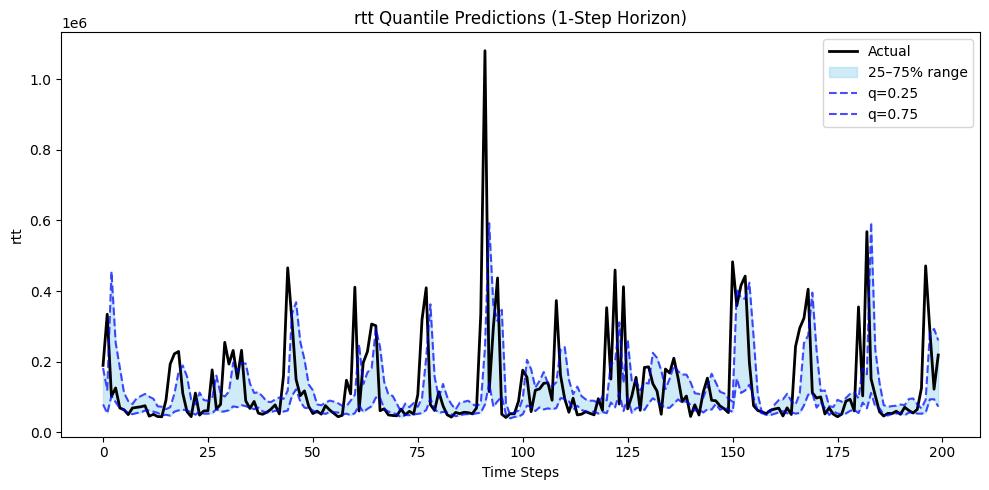


--- Horizon 4-step ---
Training quantile=0.25
0:	learn: 19521.6890330	test: 10856.3436402	best: 10856.3436402 (0)	total: 174ms	remaining: 5m 47s
200:	learn: 4273.1480204	test: 4544.3113827	best: 4544.2821816 (199)	total: 25.1s	remaining: 3m 44s
400:	learn: 4177.7367309	test: 4502.5164875	best: 4501.6589254 (396)	total: 51.7s	remaining: 3m 26s
600:	learn: 4136.7981882	test: 4479.8155967	best: 4479.8155967 (600)	total: 1m 16s	remaining: 2m 59s
800:	learn: 4110.5362820	test: 4461.9036437	best: 4461.9036437 (800)	total: 1m 43s	remaining: 2m 34s
1000:	learn: 4083.7450599	test: 4444.8760278	best: 4444.8760278 (1000)	total: 2m 6s	remaining: 2m 6s
1200:	learn: 4064.0434903	test: 4432.8289813	best: 4432.8289813 (1200)	total: 2m 28s	remaining: 1m 38s
1400:	learn: 4046.8896938	test: 4422.5300386	best: 4422.5300386 (1400)	total: 2m 50s	remaining: 1m 12s
1600:	learn: 4030.4928419	test: 4419.8147005	best: 4419.6456112 (1580)	total: 3m 12s	remaining: 48.1s
1800:	learn: 4017.3967949	test: 4415.617957

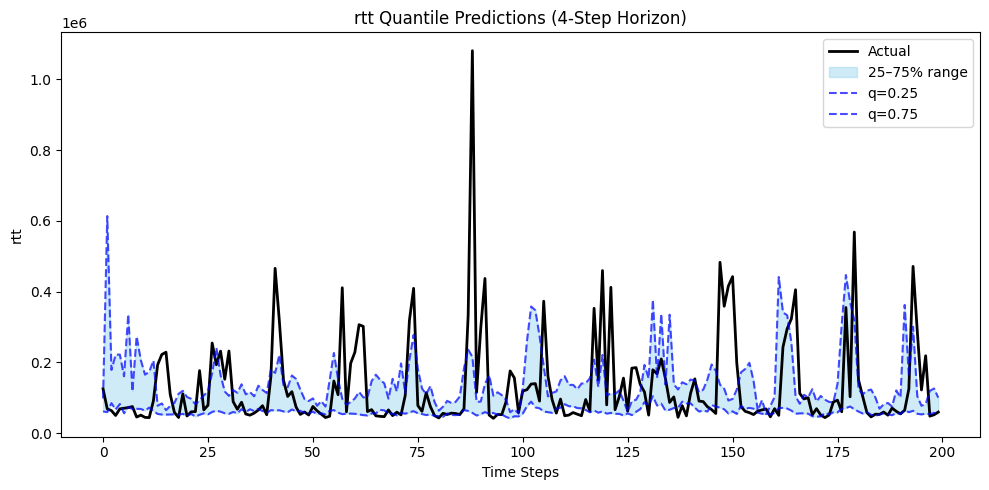


--- Horizon 16-step ---
Training quantile=0.25
0:	learn: 19520.2175271	test: 10852.5349532	best: 10852.5349532 (0)	total: 162ms	remaining: 5m 24s
200:	learn: 4336.8486526	test: 4653.9329769	best: 4653.9329769 (200)	total: 24.5s	remaining: 3m 39s
400:	learn: 4245.4967785	test: 4584.3766735	best: 4584.3766735 (400)	total: 48.7s	remaining: 3m 14s
600:	learn: 4202.0139494	test: 4555.9962934	best: 4555.5898008 (594)	total: 1m 12s	remaining: 2m 48s
800:	learn: 4172.2126827	test: 4538.8796027	best: 4538.6799935 (798)	total: 1m 34s	remaining: 2m 21s
1000:	learn: 4149.2798148	test: 4526.3558569	best: 4526.3558569 (1000)	total: 1m 57s	remaining: 1m 57s
1200:	learn: 4130.3219487	test: 4520.2416928	best: 4520.1915412 (1197)	total: 2m 19s	remaining: 1m 32s
1400:	learn: 4113.7008666	test: 4515.2036957	best: 4515.2036957 (1400)	total: 2m 40s	remaining: 1m 8s
1600:	learn: 4097.8786712	test: 4512.3978864	best: 4512.1736394 (1576)	total: 3m 1s	remaining: 45.3s
1800:	learn: 4083.4092380	test: 4512.50810

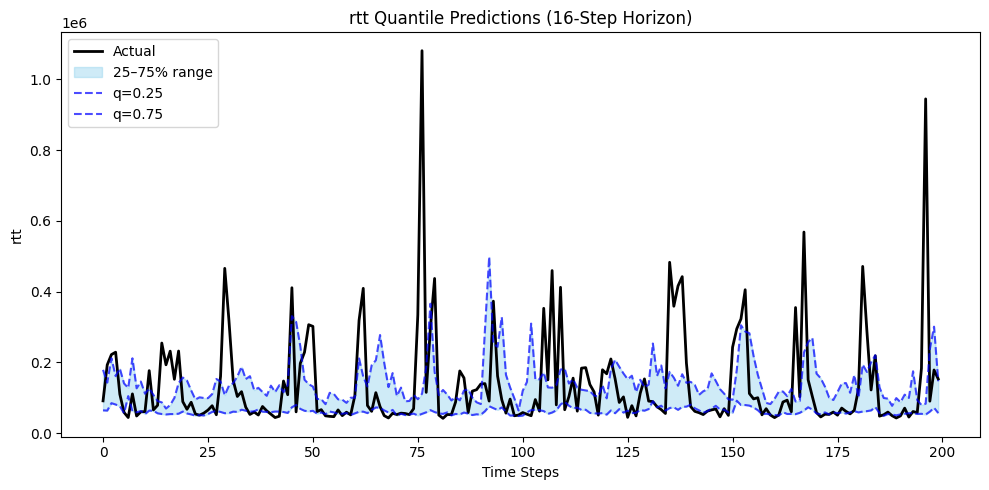

In [15]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='rtt',
    n_lags=10,
    horizons=[1, 4, 16],
    quantiles=[0.25, 0.75],
    plot=True
)


Preparing dataset for target='delivery_rate', lags=10, horizons=[1, 4, 16]
Adding lag & future target features per session...


100%|██████████| 3595/3595 [00:47<00:00, 75.45it/s]



--- Horizon 1-step ---
Training quantile=0.25
0:	learn: 2018587.8289890	test: 1571580.7543892	best: 1571580.7543892 (0)	total: 155ms	remaining: 5m 10s
200:	learn: 1100367.2666352	test: 845622.0588683	best: 845263.3545454 (196)	total: 24.2s	remaining: 3m 36s
400:	learn: 1048081.0193754	test: 825874.5362942	best: 825874.5362942 (400)	total: 47.3s	remaining: 3m 8s
600:	learn: 1024708.9684463	test: 818243.7633233	best: 818243.7633233 (600)	total: 1m 10s	remaining: 2m 44s
800:	learn: 1010754.8899638	test: 813913.8296537	best: 813913.8296537 (800)	total: 1m 34s	remaining: 2m 21s
1000:	learn: 1000487.5249108	test: 811378.0235223	best: 811378.0235223 (1000)	total: 1m 57s	remaining: 1m 57s
1200:	learn: 993451.8205129	test: 809753.5534875	best: 809753.2282019 (1199)	total: 2m 20s	remaining: 1m 33s
1400:	learn: 986920.1584745	test: 808660.7177872	best: 808601.0840464 (1385)	total: 2m 42s	remaining: 1m 9s
1600:	learn: 982813.5751667	test: 807964.9900218	best: 807964.7145751 (1598)	total: 3m 3s	re

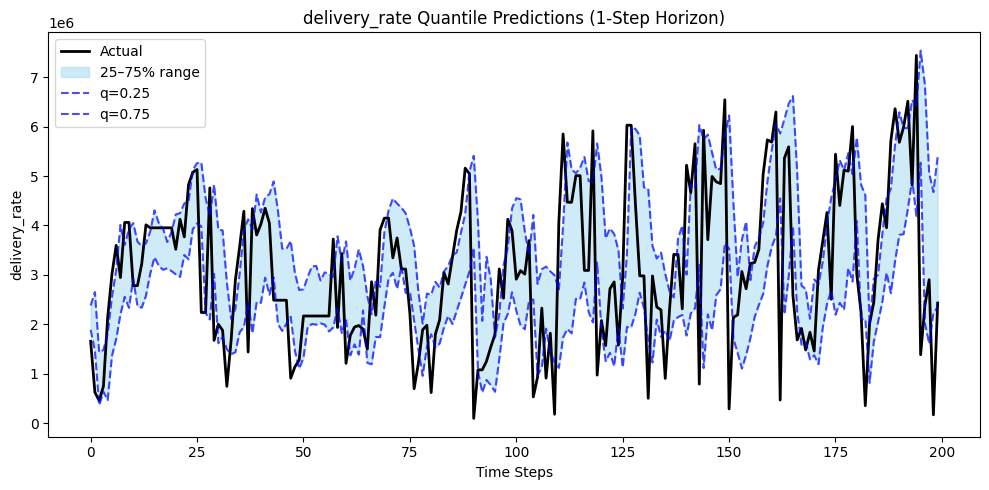


--- Horizon 4-step ---
Training quantile=0.25
0:	learn: 2019207.9000886	test: 1569797.2746526	best: 1569797.2746526 (0)	total: 123ms	remaining: 4m 5s
200:	learn: 1145644.7555137	test: 921515.0091527	best: 921510.8042938 (199)	total: 22.9s	remaining: 3m 24s
400:	learn: 1104020.1037580	test: 902199.1729335	best: 902199.1729335 (400)	total: 45.1s	remaining: 2m 59s
600:	learn: 1084051.9375851	test: 895850.1599572	best: 895843.4150771 (599)	total: 1m 8s	remaining: 2m 38s
800:	learn: 1071144.3842289	test: 893625.8712430	best: 893623.3317786 (799)	total: 1m 29s	remaining: 2m 14s
1000:	learn: 1062883.8020056	test: 892449.9295775	best: 892417.2310910 (993)	total: 1m 52s	remaining: 1m 51s
1200:	learn: 1055838.3598431	test: 891005.4865780	best: 891005.4865780 (1200)	total: 2m 13s	remaining: 1m 29s
1400:	learn: 1050651.7666302	test: 891132.7900299	best: 890567.6055445 (1377)	total: 2m 37s	remaining: 1m 7s
1600:	learn: 1044586.8215031	test: 890143.3430782	best: 890143.3430782 (1600)	total: 3m	rema

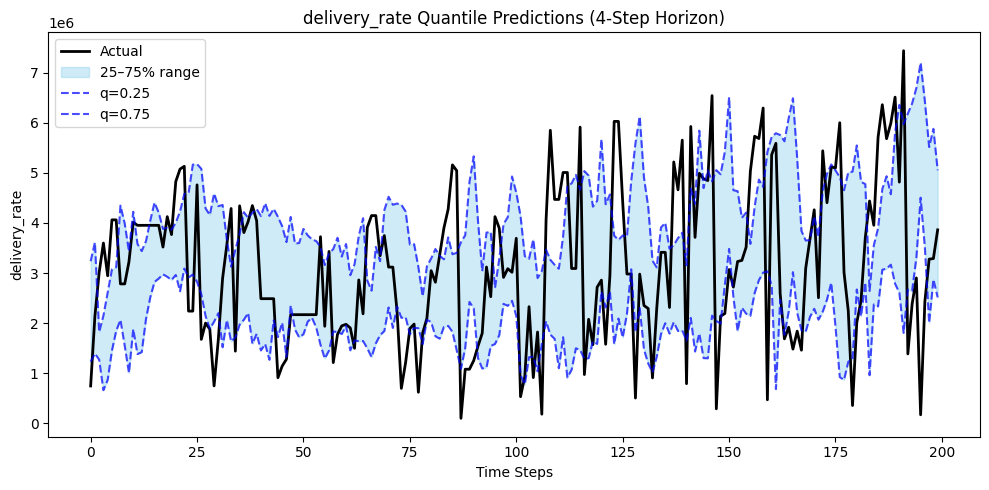


--- Horizon 16-step ---
Training quantile=0.25
0:	learn: 2029444.7997683	test: 1581954.7224147	best: 1581954.7224147 (0)	total: 110ms	remaining: 3m 40s
200:	learn: 1283178.2545834	test: 1063113.6950842	best: 1063113.6950842 (200)	total: 20.5s	remaining: 3m 3s
400:	learn: 1246653.1353163	test: 1060429.2116117	best: 1060206.4677337 (397)	total: 41.1s	remaining: 2m 43s
600:	learn: 1229429.6756038	test: 1057895.0696074	best: 1057847.5082494 (595)	total: 1m 1s	remaining: 2m 22s
800:	learn: 1216389.3219484	test: 1056609.2407721	best: 1056563.3730959 (797)	total: 1m 21s	remaining: 2m 1s
1000:	learn: 1206945.4402649	test: 1055843.7195136	best: 1055718.2609479 (951)	total: 1m 41s	remaining: 1m 41s
1200:	learn: 1197848.5229197	test: 1055717.7778355	best: 1055480.8665994 (1069)	total: 2m 1s	remaining: 1m 20s
1400:	learn: 1191234.8300246	test: 1056287.3621260	best: 1055480.8665994 (1069)	total: 2m 21s	remaining: 1m
1600:	learn: 1183793.7975391	test: 1056090.0750979	best: 1055480.8665994 (1069)	to

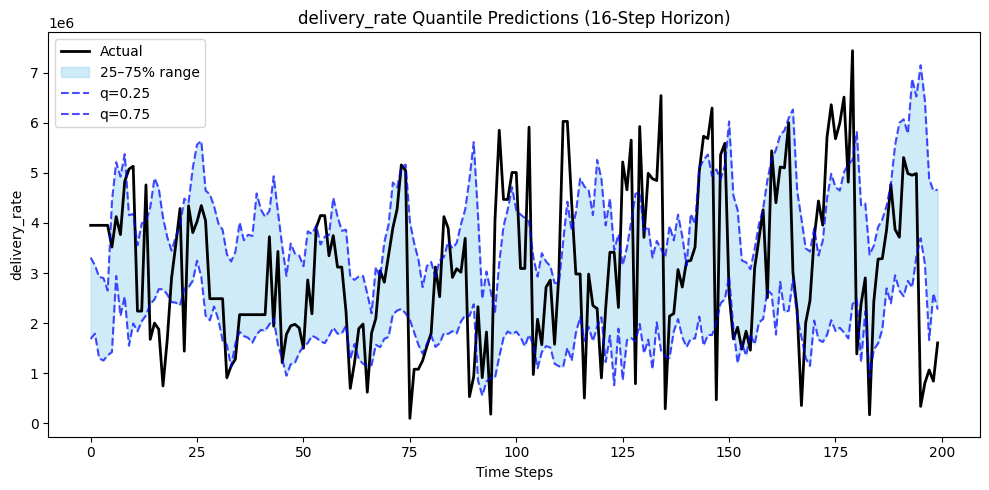

In [16]:
models, metrics = train_catboost_time_series_quantile(
    df=df,
    target_metric='delivery_rate',
    n_lags=10,
    horizons=[1, 4, 16],
    quantiles=[0.25, 0.75],
    plot=True
)